# Phase 7 Modeling Preparation

This notebook prepares the cleaned monthly gas and electricity datasets for modeling. It loads the cleaned files, removes unusable rows, validates the required columns, builds preprocessing pipelines, and transforms the training and testing data in a clean step-by-step workflow.

## Step 1. Import libraries and define file paths

Start by importing the libraries needed for loading the data, splitting the datasets, and building a preprocessing pipeline.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data" / "clean"
gas_path = data_dir / "gas_monthly_usage.csv"
electric_path = data_dir / "electric_monthly_usage.csv"

print(f"Project root: {project_root}")
print(f"Gas file: {gas_path}")
print(f"Electricity file: {electric_path}")

Project root: d:\YorkBsc\LEDIGT 2201\project
Gas file: d:\YorkBsc\LEDIGT 2201\project\data\clean\gas_monthly_usage.csv
Electricity file: d:\YorkBsc\LEDIGT 2201\project\data\clean\electric_monthly_usage.csv


## Step 2. Load the cleaned monthly datasets

Read the cleaned gas and electricity monthly usage files from the `data/clean` folder and inspect the first few rows.

In [2]:
gas_df = pd.read_csv(gas_path)
electric_df = pd.read_csv(electric_path)

print(f"Loaded gas data: {gas_df.shape[0]:,} rows x {gas_df.shape[1]} columns")
print(f"Loaded electricity data: {electric_df.shape[0]:,} rows x {electric_df.shape[1]} columns")

display(gas_df.head())
display(electric_df.head())

Loaded gas data: 8,412 rows x 6 columns
Loaded electricity data: 19,656 rows x 6 columns


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,7784.48


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,3294191.84
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,3188060.05
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,2971166.22
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,2861591.94
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,3142472.63


## Step 3. Remove unusable rows and validate required columns

For modeling, the notebook keeps only rows with valid values in the required columns:

- `Property Type - Self-Selected`
- `Gross Floor Area`
- `month`
- 
ormalized_monthly_usage`

It also removes rows where `Gross Floor Area == 1`. The `month` column is parsed as a date and then converted into month abbreviations so it can be treated as a categorical predictor instead of a continuous number.

In [14]:
REQUIRED_COLUMNS = [
    "Property Type - Self-Selected",
    "Gross Floor Area",
    "month",
    "normalized_monthly_usage",
]

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def prepare_monthly_data(frame, dataset_name):
    missing_columns = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"{dataset_name} is missing required columns: {missing_columns}")

    cleaned = frame.copy()
    rows_before = len(cleaned)

    cleaned["Gross Floor Area"] = pd.to_numeric(cleaned["Gross Floor Area"], errors="coerce")
    cleaned["normalized_monthly_usage"] = pd.to_numeric(cleaned["normalized_monthly_usage"], errors="coerce")
    cleaned["month"] = pd.to_datetime(cleaned["month"], errors="coerce")
    cleaned["Property Type - Self-Selected"] = (
        cleaned["Property Type - Self-Selected"].astype("string").str.strip()
    )

    cleaned = cleaned.loc[cleaned["Gross Floor Area"] != 1].copy()

    valid_property_type = (
        cleaned["Property Type - Self-Selected"].notna()
        & cleaned["Property Type - Self-Selected"].ne("")
    )

    valid_mask = (
        valid_property_type
        & cleaned["Gross Floor Area"].notna()
        & cleaned["month"].notna()
        & cleaned["normalized_monthly_usage"].notna()
    )

    cleaned = cleaned.loc[valid_mask].copy()
    cleaned["month"] = pd.Categorical(
        cleaned["month"].dt.strftime("%b"),
        categories=MONTH_ORDER,
        ordered=True,
    )

    summary = {
        "dataset": dataset_name,
        "rows_before": rows_before,
        "rows_after": len(cleaned),
        "rows_removed": rows_before - len(cleaned),
    }
    return cleaned, summary


gas_clean, gas_summary = prepare_monthly_data(gas_df, "Gas")
electric_clean, electric_summary = prepare_monthly_data(electric_df, "Electricity")

summary_df = pd.DataFrame([gas_summary, electric_summary])
display(summary_df)

display(gas_clean[REQUIRED_COLUMNS].head())
display(electric_clean[REQUIRED_COLUMNS].head())

,dataset,rows_before,rows_after,rows_removed
0,Gas,8412,8052,360
1,Electricity,19656,13692,5964


,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,Utilities / Infrastructure,325447,Jan,23839.31
1,Utilities / Infrastructure,325447,Feb,18735.80
2,Utilities / Infrastructure,325447,Mar,14082.81
3,Utilities / Infrastructure,325447,Apr,11537.50
4,Utilities / Infrastructure,325447,May,7784.48


,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,Utilities / Infrastructure,325447,Jan,3294191.84
1,Utilities / Infrastructure,325447,Feb,3188060.05
2,Utilities / Infrastructure,325447,Mar,2971166.22
3,Utilities / Infrastructure,325447,Apr,2861591.94
4,Utilities / Infrastructure,325447,May,3142472.63


## Step 4. Define predictors and target

The predictors for each dataset are:

- Categorical: `month`, `Property Type - Self-Selected`
- Numeric: `Gross Floor Area`

The target variable is 
ormalized_monthly_usage`.

In [15]:
categorical_features = ["month", "Property Type - Self-Selected"]
numeric_features = ["Gross Floor Area"]
target_column = "normalized_monthly_usage"

gas_X = gas_clean[categorical_features + numeric_features].copy()
gas_y = gas_clean[target_column].copy()

electric_X = electric_clean[categorical_features + numeric_features].copy()
electric_y = electric_clean[target_column].copy()

print(f"Gas X shape: {gas_X.shape}")
print(f"Gas y shape: {gas_y.shape}")
print(f"Electricity X shape: {electric_X.shape}")
print(f"Electricity y shape: {electric_y.shape}")

display(gas_X.head())
display(electric_X.head())

Gas X shape: (8052, 3)
Gas y shape: (8052,)
Electricity X shape: (13692, 3)
Electricity y shape: (13692,)


,month,Property Type - Self-Selected,Gross Floor Area
0,Jan,Utilities / Infrastructure,325447
1,Feb,Utilities / Infrastructure,325447
2,Mar,Utilities / Infrastructure,325447
3,Apr,Utilities / Infrastructure,325447
4,May,Utilities / Infrastructure,325447


,month,Property Type - Self-Selected,Gross Floor Area
0,Jan,Utilities / Infrastructure,325447
1,Feb,Utilities / Infrastructure,325447
2,Mar,Utilities / Infrastructure,325447
3,Apr,Utilities / Infrastructure,325447
4,May,Utilities / Infrastructure,325447


## Step 5. Build the preprocessing pipeline

A `ColumnTransformer` is used to apply one-hot encoding to the categorical features and pass the numeric feature through unchanged. The transformer is wrapped inside a `Pipeline` so the preprocessing steps stay organized and reusable.

In [16]:
def build_preprocessing_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("numeric", "passthrough", numeric_features),
        ]
    )

    return Pipeline(steps=[("preprocessor", preprocessor)])


gas_pipeline = build_preprocessing_pipeline()
electric_pipeline = build_preprocessing_pipeline()

gas_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

## Step 6. Apply `train_test_split`

Each dataset is split into training and testing sets before fitting the preprocessing pipeline. This prevents data leakage because the encoder will only learn categories from the training data.

In [17]:
gas_X_train, gas_X_test, gas_y_train, gas_y_test = train_test_split(
    gas_X,
    gas_y,
    test_size=0.2,
    random_state=42,
)

electric_X_train, electric_X_test, electric_y_train, electric_y_test = train_test_split(
    electric_X,
    electric_y,
    test_size=0.2,
    random_state=42,
)

split_summary = pd.DataFrame(
    [
        {
            "dataset": "Gas",
            "X_train_rows": gas_X_train.shape[0],
            "X_test_rows": gas_X_test.shape[0],
            "y_train_rows": gas_y_train.shape[0],
            "y_test_rows": gas_y_test.shape[0],
        },
        {
            "dataset": "Electricity",
            "X_train_rows": electric_X_train.shape[0],
            "X_test_rows": electric_X_test.shape[0],
            "y_train_rows": electric_y_train.shape[0],
            "y_test_rows": electric_y_test.shape[0],
        },
    ]
)

display(split_summary)

,dataset,X_train_rows,X_test_rows,y_train_rows,y_test_rows
0,Gas,6441,1611,6441,1611
1,Electricity,10953,2739,10953,2739


## Step 7. Fit the preprocessing pipeline on training data only

Now fit each pipeline using only the training predictors. After that, transform both the training and testing sets so they are ready for a machine learning model.

In [18]:
gas_pipeline.fit(gas_X_train, gas_y_train)
gas_X_train_transformed = gas_pipeline.transform(gas_X_train)
gas_X_test_transformed = gas_pipeline.transform(gas_X_test)

electric_pipeline.fit(electric_X_train, electric_y_train)
electric_X_train_transformed = electric_pipeline.transform(electric_X_train)
electric_X_test_transformed = electric_pipeline.transform(electric_X_test)

transformed_shape_summary = pd.DataFrame(
    [
        {
            "dataset": "Gas",
            "train_rows": gas_X_train_transformed.shape[0],
            "train_columns": gas_X_train_transformed.shape[1],
            "test_rows": gas_X_test_transformed.shape[0],
            "test_columns": gas_X_test_transformed.shape[1],
        },
        {
            "dataset": "Electricity",
            "train_rows": electric_X_train_transformed.shape[0],
            "train_columns": electric_X_train_transformed.shape[1],
            "test_rows": electric_X_test_transformed.shape[0],
            "test_columns": electric_X_test_transformed.shape[1],
        },
    ]
)

display(transformed_shape_summary)

,dataset,train_rows,train_columns,test_rows,test_columns
0,Gas,6441,20,1611,20
1,Electricity,10953,20,2739,20


## Step 8. View the encoded feature names

After fitting the preprocessing pipeline, the `ColumnTransformer` can report the output feature names. This is useful when interpreting the transformed matrix and checking that `month` and `Property Type - Self-Selected` were encoded correctly.

In [19]:
gas_feature_names = gas_pipeline.named_steps["preprocessor"].get_feature_names_out()
electric_feature_names = electric_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"Gas encoded feature count: {len(gas_feature_names)}")
display(pd.Series(gas_feature_names, name="gas_feature_names"))

print(f"Electricity encoded feature count: {len(electric_feature_names)}")
display(pd.Series(electric_feature_names, name="electricity_feature_names"))

Gas encoded feature count: 20


0                                categorical__month_Apr
1                                categorical__month_Aug
2                                categorical__month_Dec
3                                categorical__month_Feb
4                                categorical__month_Jan
5                                categorical__month_Jul
6                                categorical__month_Jun
7                                categorical__month_Mar
8                                categorical__month_May
9                                categorical__month_Nov
10                               categorical__month_Oct
11                               categorical__month_Sep
12    categorical__Property Type - Self-Selected_Adm...
13    categorical__Property Type - Self-Selected_Edu...
14    categorical__Property Type - Self-Selected_Oth...
15    categorical__Property Type - Self-Selected_Pub...
16    categorical__Property Type - Self-Selected_Rec...
17    categorical__Property Type - Self-Selected

Electricity encoded feature count: 20


0                                categorical__month_Apr
1                                categorical__month_Aug
2                                categorical__month_Dec
3                                categorical__month_Feb
4                                categorical__month_Jan
5                                categorical__month_Jul
6                                categorical__month_Jun
7                                categorical__month_Mar
8                                categorical__month_May
9                                categorical__month_Nov
10                               categorical__month_Oct
11                               categorical__month_Sep
12    categorical__Property Type - Self-Selected_Adm...
13    categorical__Property Type - Self-Selected_Edu...
14    categorical__Property Type - Self-Selected_Oth...
15    categorical__Property Type - Self-Selected_Pub...
16    categorical__Property Type - Self-Selected_Rec...
17    categorical__Property Type - Self-Selected

## Train gas linear regression model

Use the existing gas training data and preprocessing logic to fit a baseline `LinearRegression` model. The preprocessing step and model are combined in a single pipeline.

In [20]:
from sklearn.base import clone
from sklearn.linear_model import LinearRegression

# Reuse the same preprocessing structure inside a full modeling pipeline.
gas_model = Pipeline(steps=[
    ("preprocessor", clone(gas_pipeline.named_steps["preprocessor"])),
    ("model", LinearRegression()),
])

gas_model.fit(gas_X_train, gas_y_train)
gas_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## Train electricity linear regression model

Repeat the same baseline regression workflow for the electricity dataset so the two energy types stay separate.

In [21]:
electric_model = Pipeline(steps=[
    ("preprocessor", clone(electric_pipeline.named_steps["preprocessor"])),
    ("model", LinearRegression()),
])

electric_model.fit(electric_X_train, electric_y_train)
electric_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## Generate predictions for train and test sets

After training the models, generate predictions for both the training and testing splits. This keeps the baseline workflow ready for evaluation in the next phase.

In [23]:
gas_train_pred = gas_model.predict(gas_X_train)
gas_test_pred = gas_model.predict(gas_X_test)

electric_train_pred = electric_model.predict(electric_X_train)
electric_test_pred = electric_model.predict(electric_X_test)

prediction_summary = pd.DataFrame(
    [
        {"dataset": "Gas", "split": "Train", "predictions": len(gas_train_pred)},
        {"dataset": "Gas", "split": "Test", "predictions": len(gas_test_pred)},
        {"dataset": "Electricity", "split": "Train", "predictions": len(electric_train_pred)},
        {"dataset": "Electricity", "split": "Test", "predictions": len(electric_test_pred)},
    ]
)

display(prediction_summary)

,dataset,split,predictions
0,Gas,Train,6441
1,Gas,Test,1611
2,Electricity,Train,10953
3,Electricity,Test,2739


## Display sample actual vs predicted values

Compare a few actual target values with the model predictions for each dataset. These quick tables are useful for a first visual check before calculating formal evaluation metrics.

In [24]:
def sample_predictions(actual_values, predicted_values, rows=5):
    results = pd.DataFrame({
        "actual": actual_values.reset_index(drop=True),
        "predicted": pd.Series(predicted_values),
    })
    results["actual"] = results["actual"].round(2)
    results["predicted"] = results["predicted"].round(2)
    return results.head(rows)

print("Gas training sample")
display(sample_predictions(gas_y_train, gas_train_pred))

print("Gas testing sample")
display(sample_predictions(gas_y_test, gas_test_pred))

print("Electricity training sample")
display(sample_predictions(electric_y_train, electric_train_pred))

print("Electricity testing sample")
display(sample_predictions(electric_y_test, electric_test_pred))

Gas training sample


,actual,predicted
0,1970.30,1183.36
1,6383.33,4886.92
2,190.13,2168.42
3,582.17,20823.69
4,605.45,2136.71


Gas testing sample


,actual,predicted
0,2320.03,2801.87
1,16494.08,5687.59
2,337.59,8489.94
3,474.38,2008.39
4,3364.27,4282.57


Electricity training sample


,actual,predicted
0,74.12,-35207.64
1,157.93,-20526.50
2,115996.26,104341.80
3,25740.60,32189.77
4,606.33,-24978.99


Electricity testing sample


,actual,predicted
0,1768.12,-19065.69
1,792799.02,1622416.08
2,756.77,-20613.67
3,8735.98,23876.96
4,14797.38,55219.58


## Summary

This section trained two separate baseline linear regression models: one for natural gas and one for electricity. The next phase will evaluate these baseline models with metrics and plots to understand how well they perform.

## Improved linear regression (outlier removal + log transformations)
This section repeats the baseline modeling workflow with two upgrades: outlier removal and log transformations.

## Step 1. Import additional libraries for evaluation and plotting

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2. Rebuild cleaned datasets while keeping `Portfolio Manager ID`
Then remove outliers by property-level usage and by top 1% gross floor area.

In [27]:
ID_COLUMN = "Portfolio Manager ID"
IMPROVED_REQUIRED_COLUMNS = [
    ID_COLUMN,
    "Property Type - Self-Selected",
    "Gross Floor Area",
    "month",
    "normalized_monthly_usage",
]


def prepare_monthly_data_with_id(frame, dataset_name):
    missing_columns = [column for column in IMPROVED_REQUIRED_COLUMNS if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"{dataset_name} is missing required columns: {missing_columns}")

    cleaned = frame.copy()
    rows_before = len(cleaned)

    cleaned[ID_COLUMN] = cleaned[ID_COLUMN].astype("string").str.strip()
    cleaned["Gross Floor Area"] = pd.to_numeric(cleaned["Gross Floor Area"], errors="coerce")
    cleaned["normalized_monthly_usage"] = pd.to_numeric(cleaned["normalized_monthly_usage"], errors="coerce")
    cleaned["month"] = pd.to_datetime(cleaned["month"], errors="coerce")
    cleaned["Property Type - Self-Selected"] = (
        cleaned["Property Type - Self-Selected"].astype("string").str.strip()
    )

    cleaned = cleaned.loc[cleaned["Gross Floor Area"] != 1].copy()

    valid_property_type = (
        cleaned["Property Type - Self-Selected"].notna()
        & cleaned["Property Type - Self-Selected"].ne("")
    )

    valid_property_id = cleaned[ID_COLUMN].notna() & cleaned[ID_COLUMN].ne("")

    valid_mask = (
        valid_property_type
        & valid_property_id
        & cleaned["Gross Floor Area"].notna()
        & cleaned["month"].notna()
        & cleaned["normalized_monthly_usage"].notna()
    )

    cleaned = cleaned.loc[valid_mask].copy()
    cleaned["month"] = pd.Categorical(
        cleaned["month"].dt.strftime("%b"),
        categories=MONTH_ORDER,
        ordered=True,
    )

    summary = {
        "dataset": dataset_name,
        "rows_before": rows_before,
        "rows_after": len(cleaned),
        "rows_removed": rows_before - len(cleaned),
        "unique_property_ids_after": cleaned[ID_COLUMN].nunique(),
    }
    return cleaned, summary


def remove_top_one_percent_outliers(frame, dataset_name):
    cleaned = frame.copy()

    property_usage = (
        cleaned.groupby(ID_COLUMN, as_index=False)["normalized_monthly_usage"]
        .mean()
        .rename(columns={"normalized_monthly_usage": "avg_normalized_monthly_usage"})
    )

    property_count = len(property_usage)
    outlier_property_count = max(1, int(np.ceil(property_count * 0.01))) if property_count > 0 else 0

    usage_outlier_property_ids = (
        property_usage
        .nlargest(outlier_property_count, "avg_normalized_monthly_usage")[ID_COLUMN]
        if outlier_property_count > 0
        else pd.Series(dtype="string")
    )

    after_usage_outlier_removal = cleaned.loc[
        ~cleaned[ID_COLUMN].isin(usage_outlier_property_ids)
    ].copy()

    rows_removed_usage = len(cleaned) - len(after_usage_outlier_removal)
    unique_ids_removed_usage = cleaned.loc[
        cleaned[ID_COLUMN].isin(usage_outlier_property_ids), ID_COLUMN
    ].nunique()

    area_outlier_row_count = (
        max(1, int(np.ceil(len(after_usage_outlier_removal) * 0.01)))
        if len(after_usage_outlier_removal) > 0
        else 0
    )

    area_outlier_indices = (
        after_usage_outlier_removal["Gross Floor Area"].nlargest(area_outlier_row_count).index
        if area_outlier_row_count > 0
        else pd.Index([])
    )

    area_outlier_property_ids = after_usage_outlier_removal.loc[area_outlier_indices, ID_COLUMN]

    after_all_outlier_removal = after_usage_outlier_removal.drop(index=area_outlier_indices).copy()

    rows_removed_area = len(after_usage_outlier_removal) - len(after_all_outlier_removal)
    unique_ids_removed_area = area_outlier_property_ids.nunique()

    removed_row_indices = cleaned.index.difference(after_all_outlier_removal.index)
    unique_ids_with_any_removed_rows = cleaned.loc[removed_row_indices, ID_COLUMN].nunique()

    summary = {
        "dataset": dataset_name,
        "rows_before_outlier_removal": len(cleaned),
        "rows_after_outlier_removal": len(after_all_outlier_removal),
        "rows_removed_total": len(cleaned) - len(after_all_outlier_removal),
        "unique_property_ids_with_removed_rows": unique_ids_with_any_removed_rows,
        "usage_outlier_property_ids_count": unique_ids_removed_usage,
        "rows_removed_by_usage_outliers": rows_removed_usage,
        "rows_removed_by_area_outliers": rows_removed_area,
        "unique_property_ids_in_area_removed_rows": unique_ids_removed_area,
    }

    return after_all_outlier_removal, summary


improved_gas_clean, improved_gas_clean_summary = prepare_monthly_data_with_id(gas_df, "Gas")
improved_electric_clean, improved_electric_clean_summary = prepare_monthly_data_with_id(electric_df, "Electricity")

improved_gas_cleaned, improved_gas_outlier_summary = remove_top_one_percent_outliers(
    improved_gas_clean,
    "Gas",
)
improved_electric_cleaned, improved_electric_outlier_summary = remove_top_one_percent_outliers(
    improved_electric_clean,
    "Electricity",
)

cleaning_summary_df = pd.DataFrame([improved_gas_clean_summary, improved_electric_clean_summary])
outlier_summary_df = pd.DataFrame([improved_gas_outlier_summary, improved_electric_outlier_summary])

print("Initial cleaning summary")
display(cleaning_summary_df)

print("Outlier removal summary")
display(outlier_summary_df)

display(improved_gas_cleaned[[ID_COLUMN] + REQUIRED_COLUMNS].head())
display(improved_electric_cleaned[[ID_COLUMN] + REQUIRED_COLUMNS].head())

Initial cleaning summary


,dataset,rows_before,rows_after,rows_removed,unique_property_ids_after
0,Gas,8412,8052,360,671
1,Electricity,19656,13692,5964,1141


Outlier removal summary


,dataset,rows_before_outlier_removal,rows_after_outlier_removal,rows_removed_total,unique_property_ids_with_removed_rows,usage_outlier_property_ids_count,rows_removed_by_usage_outliers,rows_removed_by_area_outliers,unique_property_ids_in_area_removed_rows
0,Gas,8052,7888,164,14,7,84,80,7
1,Electricity,13692,13412,280,24,12,144,136,12


,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,35000838,Utilities / Infrastructure,325447,Jan,23839.31
1,35000838,Utilities / Infrastructure,325447,Feb,18735.80
2,35000838,Utilities / Infrastructure,325447,Mar,14082.81
3,35000838,Utilities / Infrastructure,325447,Apr,11537.50
4,35000838,Utilities / Infrastructure,325447,May,7784.48


,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
12,35000839,Utilities / Infrastructure,64196,Jan,431482.13
13,35000839,Utilities / Infrastructure,64196,Feb,370593.50
14,35000839,Utilities / Infrastructure,64196,Mar,698637.54
15,35000839,Utilities / Infrastructure,64196,Apr,641432.37
16,35000839,Utilities / Infrastructure,64196,May,585490.93


## Step 3. Create log-transformed target and numeric feature

In [28]:
improved_gas_modeling_df = improved_gas_cleaned.copy()
improved_electric_modeling_df = improved_electric_cleaned.copy()

improved_gas_modeling_df["log_normalized_monthly_usage"] = np.log1p(
    improved_gas_modeling_df["normalized_monthly_usage"]
)
improved_electric_modeling_df["log_normalized_monthly_usage"] = np.log1p(
    improved_electric_modeling_df["normalized_monthly_usage"]
)

improved_gas_modeling_df["log_gross_floor_area"] = np.log1p(
    improved_gas_modeling_df["Gross Floor Area"]
)
improved_electric_modeling_df["log_gross_floor_area"] = np.log1p(
    improved_electric_modeling_df["Gross Floor Area"]
)

improved_categorical_features = ["month", "Property Type - Self-Selected"]
improved_numeric_features = ["log_gross_floor_area"]
improved_target_column = "log_normalized_monthly_usage"

improved_modeling_columns = [
    ID_COLUMN,
    "month",
    "Property Type - Self-Selected",
    "Gross Floor Area",
    "normalized_monthly_usage",
    "log_gross_floor_area",
    "log_normalized_monthly_usage",
]

improved_gas_modeling_df = improved_gas_modeling_df[improved_modeling_columns].copy()
improved_electric_modeling_df = improved_electric_modeling_df[improved_modeling_columns].copy()

improved_gas_X_full = improved_gas_modeling_df[[ID_COLUMN] + improved_categorical_features + improved_numeric_features].copy()
improved_electric_X_full = improved_electric_modeling_df[[ID_COLUMN] + improved_categorical_features + improved_numeric_features].copy()

improved_gas_y_log = improved_gas_modeling_df[improved_target_column].copy()
improved_electric_y_log = improved_electric_modeling_df[improved_target_column].copy()

improved_gas_y = improved_gas_modeling_df["normalized_monthly_usage"].copy()
improved_electric_y = improved_electric_modeling_df["normalized_monthly_usage"].copy()

print(f"Improved gas modeling data shape: {improved_gas_modeling_df.shape}")
print(f"Improved electricity modeling data shape: {improved_electric_modeling_df.shape}")

display(improved_gas_modeling_df.head())
display(improved_electric_modeling_df.head())

Improved gas modeling data shape: (7888, 7)
Improved electricity modeling data shape: (13412, 7)


,Portfolio Manager ID,month,Property Type - Self-Selected,Gross Floor Area,normalized_monthly_usage,log_gross_floor_area,log_normalized_monthly_usage
0,35000838,Jan,Utilities / Infrastructure,325447,23839.31,12.692958,10.079133
1,35000838,Feb,Utilities / Infrastructure,325447,18735.80,12.692958,9.838245
2,35000838,Mar,Utilities / Infrastructure,325447,14082.81,12.692958,9.552781
3,35000838,Apr,Utilities / Infrastructure,325447,11537.50,12.692958,9.353445
4,35000838,May,Utilities / Infrastructure,325447,7784.48,12.692958,8.960016


,Portfolio Manager ID,month,Property Type - Self-Selected,Gross Floor Area,normalized_monthly_usage,log_gross_floor_area,log_normalized_monthly_usage
12,35000839,Jan,Utilities / Infrastructure,64196,431482.13,11.069712,12.974984
13,35000839,Feb,Utilities / Infrastructure,64196,370593.50,11.069712,12.822864
14,35000839,Mar,Utilities / Infrastructure,64196,698637.54,11.069712,13.456889
15,35000839,Apr,Utilities / Infrastructure,64196,641432.37,11.069712,13.371461
16,35000839,May,Utilities / Infrastructure,64196,585490.93,11.069712,13.280208


## Step 4. Build the improved preprocessing pipeline

In [29]:
def build_improved_preprocessing_pipeline():
    preprocessor = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), improved_categorical_features),
            ("numeric", "passthrough", improved_numeric_features),
        ]
    )

    return Pipeline(steps=[("preprocessor", preprocessor)])


improved_gas_pipeline = build_improved_preprocessing_pipeline()
improved_electric_pipeline = build_improved_preprocessing_pipeline()

improved_gas_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

## Step 5. Apply `train_test_split`

In [30]:
(
    improved_gas_X_train_full,
    improved_gas_X_test_full,
    improved_gas_y_train_log,
    improved_gas_y_test_log,
    improved_gas_y_train,
    improved_gas_y_test,
) = train_test_split(
    improved_gas_X_full,
    improved_gas_y_log,
    improved_gas_y,
    test_size=0.2,
    random_state=42,
)

(
    improved_electric_X_train_full,
    improved_electric_X_test_full,
    improved_electric_y_train_log,
    improved_electric_y_test_log,
    improved_electric_y_train,
    improved_electric_y_test,
) = train_test_split(
    improved_electric_X_full,
    improved_electric_y_log,
    improved_electric_y,
    test_size=0.2,
    random_state=42,
)

improved_gas_X_train = improved_gas_X_train_full.drop(columns=[ID_COLUMN]).copy()
improved_gas_X_test = improved_gas_X_test_full.drop(columns=[ID_COLUMN]).copy()

improved_electric_X_train = improved_electric_X_train_full.drop(columns=[ID_COLUMN]).copy()
improved_electric_X_test = improved_electric_X_test_full.drop(columns=[ID_COLUMN]).copy()

improved_split_summary = pd.DataFrame(
    [
        {
            "dataset": "Gas",
            "X_train_rows": improved_gas_X_train.shape[0],
            "X_test_rows": improved_gas_X_test.shape[0],
            "y_train_rows": improved_gas_y_train_log.shape[0],
            "y_test_rows": improved_gas_y_test_log.shape[0],
            "train_unique_property_ids": improved_gas_X_train_full[ID_COLUMN].nunique(),
            "test_unique_property_ids": improved_gas_X_test_full[ID_COLUMN].nunique(),
        },
        {
            "dataset": "Electricity",
            "X_train_rows": improved_electric_X_train.shape[0],
            "X_test_rows": improved_electric_X_test.shape[0],
            "y_train_rows": improved_electric_y_train_log.shape[0],
            "y_test_rows": improved_electric_y_test_log.shape[0],
            "train_unique_property_ids": improved_electric_X_train_full[ID_COLUMN].nunique(),
            "test_unique_property_ids": improved_electric_X_test_full[ID_COLUMN].nunique(),
        },
    ]
)

display(improved_split_summary)

,dataset,X_train_rows,X_test_rows,y_train_rows,y_test_rows,train_unique_property_ids,test_unique_property_ids
0,Gas,6310,1578,6310,1578,658,602
1,Electricity,10729,2683,10729,2683,1118,1022


## Step 6. Fit the preprocessing pipeline on training data only

In [31]:
improved_gas_pipeline.fit(improved_gas_X_train, improved_gas_y_train_log)
improved_gas_X_train_transformed = improved_gas_pipeline.transform(improved_gas_X_train)
improved_gas_X_test_transformed = improved_gas_pipeline.transform(improved_gas_X_test)

improved_electric_pipeline.fit(improved_electric_X_train, improved_electric_y_train_log)
improved_electric_X_train_transformed = improved_electric_pipeline.transform(improved_electric_X_train)
improved_electric_X_test_transformed = improved_electric_pipeline.transform(improved_electric_X_test)

improved_transformed_shape_summary = pd.DataFrame(
    [
        {
            "dataset": "Gas",
            "train_rows": improved_gas_X_train_transformed.shape[0],
            "train_columns": improved_gas_X_train_transformed.shape[1],
            "test_rows": improved_gas_X_test_transformed.shape[0],
            "test_columns": improved_gas_X_test_transformed.shape[1],
        },
        {
            "dataset": "Electricity",
            "train_rows": improved_electric_X_train_transformed.shape[0],
            "train_columns": improved_electric_X_train_transformed.shape[1],
            "test_rows": improved_electric_X_test_transformed.shape[0],
            "test_columns": improved_electric_X_test_transformed.shape[1],
        },
    ]
)

display(improved_transformed_shape_summary)

,dataset,train_rows,train_columns,test_rows,test_columns
0,Gas,6310,20,1578,20
1,Electricity,10729,20,2683,20


## Step 7. View the encoded feature names

In [32]:
improved_gas_feature_names = improved_gas_pipeline.named_steps["preprocessor"].get_feature_names_out()
improved_electric_feature_names = improved_electric_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(f"Improved gas encoded feature count: {len(improved_gas_feature_names)}")
display(pd.Series(improved_gas_feature_names, name="improved_gas_feature_names"))

print(f"Improved electricity encoded feature count: {len(improved_electric_feature_names)}")
display(pd.Series(improved_electric_feature_names, name="improved_electric_feature_names"))

Improved gas encoded feature count: 20


0                                categorical__month_Apr
1                                categorical__month_Aug
2                                categorical__month_Dec
3                                categorical__month_Feb
4                                categorical__month_Jan
5                                categorical__month_Jul
6                                categorical__month_Jun
7                                categorical__month_Mar
8                                categorical__month_May
9                                categorical__month_Nov
10                               categorical__month_Oct
11                               categorical__month_Sep
12    categorical__Property Type - Self-Selected_Adm...
13    categorical__Property Type - Self-Selected_Edu...
14    categorical__Property Type - Self-Selected_Oth...
15    categorical__Property Type - Self-Selected_Pub...
16    categorical__Property Type - Self-Selected_Rec...
17    categorical__Property Type - Self-Selected

Improved electricity encoded feature count: 20


0                                categorical__month_Apr
1                                categorical__month_Aug
2                                categorical__month_Dec
3                                categorical__month_Feb
4                                categorical__month_Jan
5                                categorical__month_Jul
6                                categorical__month_Jun
7                                categorical__month_Mar
8                                categorical__month_May
9                                categorical__month_Nov
10                               categorical__month_Oct
11                               categorical__month_Sep
12    categorical__Property Type - Self-Selected_Adm...
13    categorical__Property Type - Self-Selected_Edu...
14    categorical__Property Type - Self-Selected_Oth...
15    categorical__Property Type - Self-Selected_Pub...
16    categorical__Property Type - Self-Selected_Rec...
17    categorical__Property Type - Self-Selected

## Train improved gas linear regression model

In [33]:
improved_gas_model = Pipeline(steps=[
    ("preprocessor", clone(improved_gas_pipeline.named_steps["preprocessor"])),
    ("model", LinearRegression()),
])

improved_gas_model.fit(improved_gas_X_train, improved_gas_y_train_log)
improved_gas_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## Train improved electricity linear regression model

In [34]:
improved_electric_model = Pipeline(steps=[
    ("preprocessor", clone(improved_electric_pipeline.named_steps["preprocessor"])),
    ("model", LinearRegression()),
])

improved_electric_model.fit(improved_electric_X_train, improved_electric_y_train_log)
improved_electric_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## Generate predictions for train and test sets

In [35]:
improved_gas_train_pred_log = improved_gas_model.predict(improved_gas_X_train)
improved_gas_test_pred_log = improved_gas_model.predict(improved_gas_X_test)

improved_electric_train_pred_log = improved_electric_model.predict(improved_electric_X_train)
improved_electric_test_pred_log = improved_electric_model.predict(improved_electric_X_test)

improved_gas_train_pred = np.expm1(improved_gas_train_pred_log)
improved_gas_test_pred = np.expm1(improved_gas_test_pred_log)

improved_electric_train_pred = np.expm1(improved_electric_train_pred_log)
improved_electric_test_pred = np.expm1(improved_electric_test_pred_log)

improved_prediction_summary = pd.DataFrame(
    [
        {"dataset": "Gas", "split": "Train", "predictions": len(improved_gas_train_pred_log)},
        {"dataset": "Gas", "split": "Test", "predictions": len(improved_gas_test_pred_log)},
        {"dataset": "Electricity", "split": "Train", "predictions": len(improved_electric_train_pred_log)},
        {"dataset": "Electricity", "split": "Test", "predictions": len(improved_electric_test_pred_log)},
    ]
)

display(improved_prediction_summary)

,dataset,split,predictions
0,Gas,Train,6310
1,Gas,Test,1578
2,Electricity,Train,10729
3,Electricity,Test,2683


## Step 8. Evaluate model performance (`R^2`, MAE, RMSE)

In [36]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }


improved_log_metrics = pd.DataFrame(
    [
        {"dataset": "Gas", "split": "Train", **regression_metrics(improved_gas_y_train_log, improved_gas_train_pred_log)},
        {"dataset": "Gas", "split": "Test", **regression_metrics(improved_gas_y_test_log, improved_gas_test_pred_log)},
        {"dataset": "Electricity", "split": "Train", **regression_metrics(improved_electric_y_train_log, improved_electric_train_pred_log)},
        {"dataset": "Electricity", "split": "Test", **regression_metrics(improved_electric_y_test_log, improved_electric_test_pred_log)},
    ]
)

improved_original_scale_metrics = pd.DataFrame(
    [
        {"dataset": "Gas", "split": "Train", **regression_metrics(improved_gas_y_train, improved_gas_train_pred)},
        {"dataset": "Gas", "split": "Test", **regression_metrics(improved_gas_y_test, improved_gas_test_pred)},
        {"dataset": "Electricity", "split": "Train", **regression_metrics(improved_electric_y_train, improved_electric_train_pred)},
        {"dataset": "Electricity", "split": "Test", **regression_metrics(improved_electric_y_test, improved_electric_test_pred)},
    ]
)

print("Improved model metrics in log space (training target)")
display(improved_log_metrics.round(4))

print("Improved model metrics on original usage scale (for interpretation/comparison)")
display(improved_original_scale_metrics.round(4))

Improved model metrics in log space (training target)


,dataset,split,R2,MAE,RMSE
0,Gas,Train,0.4502,1.2267,1.8204
1,Gas,Test,0.4593,1.2237,1.8190
2,Electricity,Train,0.4110,1.2842,1.8122
3,Electricity,Test,0.4182,1.2777,1.8122


Improved model metrics on original usage scale (for interpretation/comparison)


,dataset,split,R2,MAE,RMSE
0,Gas,Train,0.1511,2974.9902,10499.3889
1,Gas,Test,0.0865,3325.0600,13705.9324
2,Electricity,Train,0.1853,22720.5826,71871.5752
3,Electricity,Test,0.1891,24006.9685,78536.8766


## Residual plots

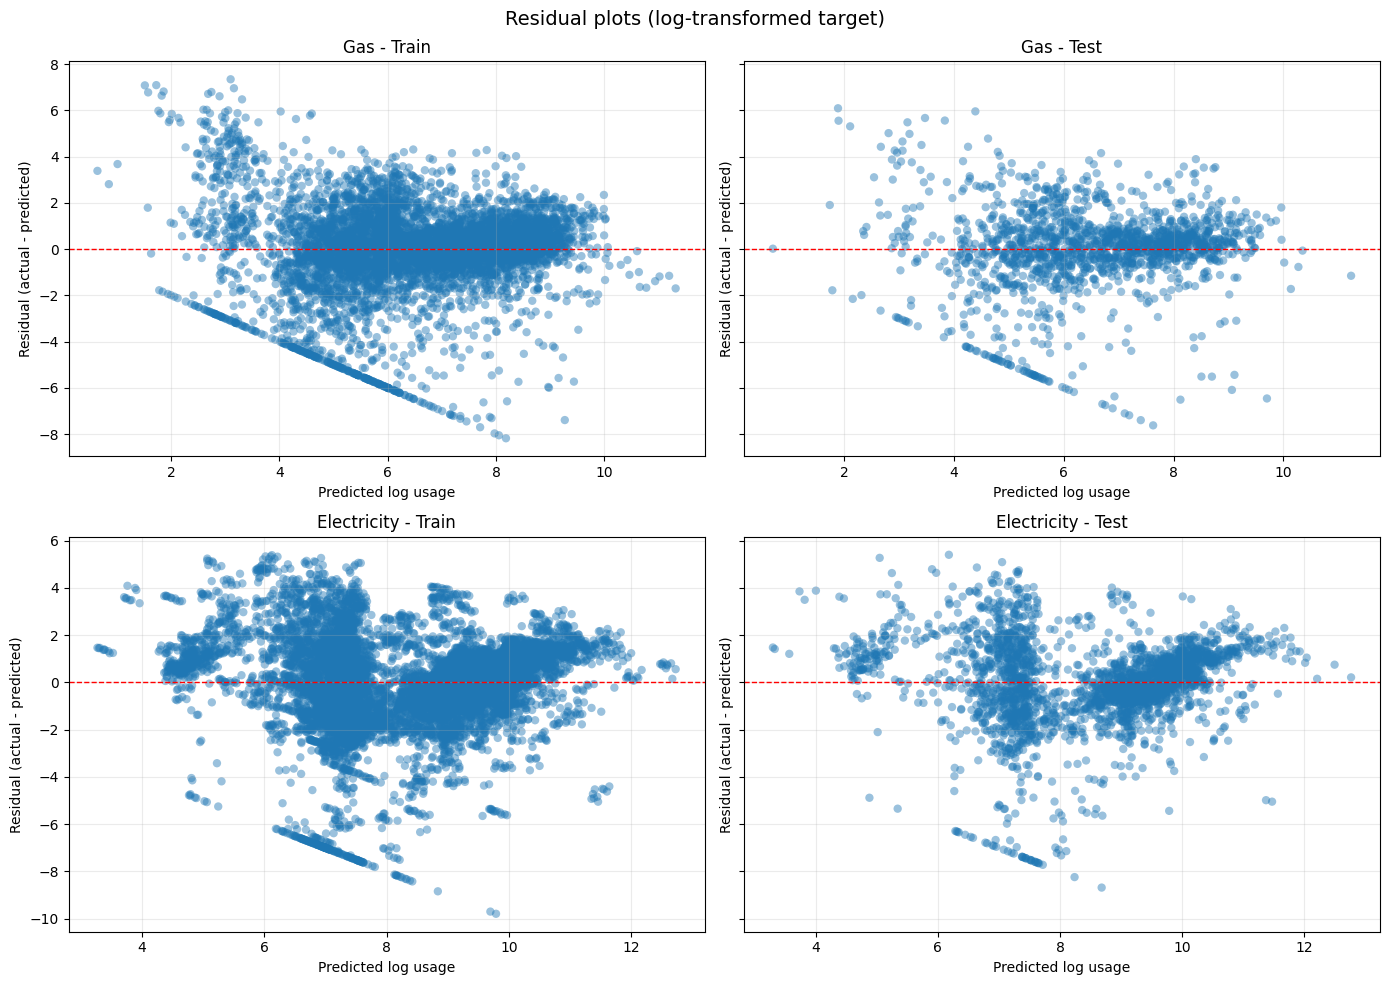

In [37]:
def plot_residuals_grid():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey="row")

    plot_data = [
        ("Gas", "Train", improved_gas_train_pred_log, improved_gas_y_train_log),
        ("Gas", "Test", improved_gas_test_pred_log, improved_gas_y_test_log),
        ("Electricity", "Train", improved_electric_train_pred_log, improved_electric_y_train_log),
        ("Electricity", "Test", improved_electric_test_pred_log, improved_electric_y_test_log),
    ]

    for ax, (dataset, split, y_pred_log, y_true_log) in zip(axes.ravel(), plot_data):
        residuals = y_true_log - y_pred_log
        ax.scatter(y_pred_log, residuals, alpha=0.45, edgecolor="none")
        ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
        ax.set_title(f"{dataset} - {split}")
        ax.set_xlabel("Predicted log usage")
        ax.set_ylabel("Residual (actual - predicted)")
        ax.grid(alpha=0.25)

    fig.suptitle("Residual plots (log-transformed target)", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_residuals_grid()

## Predicted vs actual plots

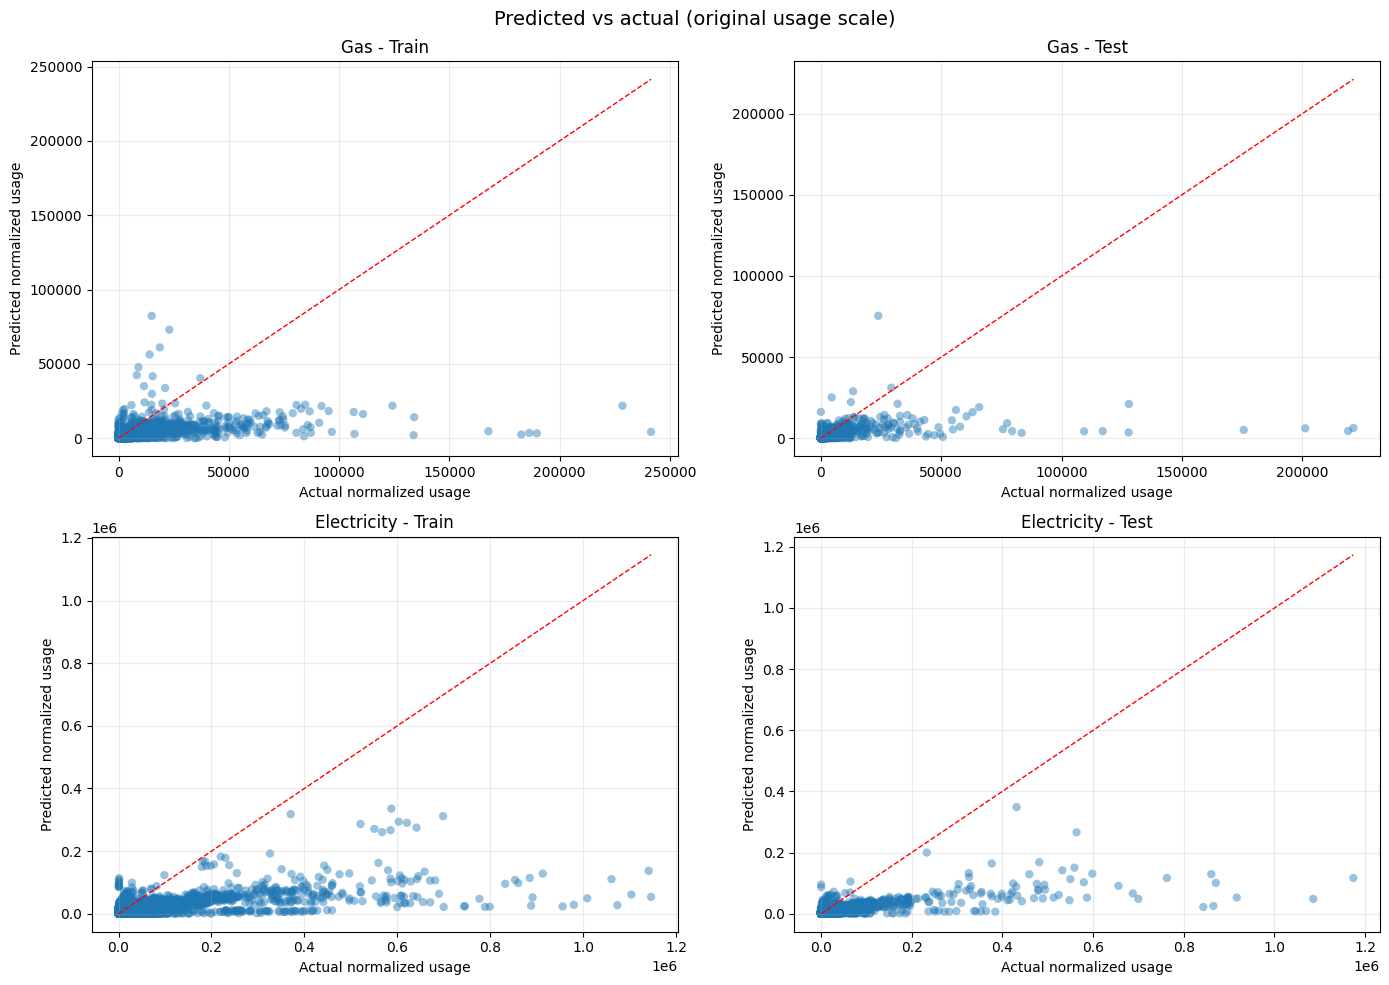

In [38]:
def plot_predicted_vs_actual_grid():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_data = [
        ("Gas", "Train", improved_gas_y_train, improved_gas_train_pred),
        ("Gas", "Test", improved_gas_y_test, improved_gas_test_pred),
        ("Electricity", "Train", improved_electric_y_train, improved_electric_train_pred),
        ("Electricity", "Test", improved_electric_y_test, improved_electric_test_pred),
    ]

    for ax, (dataset, split, y_true, y_pred) in zip(axes.ravel(), plot_data):
        ax.scatter(y_true, y_pred, alpha=0.45, edgecolor="none")
        axis_min = min(np.min(y_true), np.min(y_pred))
        axis_max = max(np.max(y_true), np.max(y_pred))
        ax.plot([axis_min, axis_max], [axis_min, axis_max], "r--", linewidth=1)
        ax.set_title(f"{dataset} - {split}")
        ax.set_xlabel("Actual normalized usage")
        ax.set_ylabel("Predicted normalized usage")
        ax.grid(alpha=0.25)

    fig.suptitle("Predicted vs actual (original usage scale)", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_predicted_vs_actual_grid()

## Baseline vs improved comparison

In [39]:
baseline_metrics = pd.DataFrame(
    [
        {"dataset": "Gas", "split": "Train", **regression_metrics(gas_y_train, gas_train_pred)},
        {"dataset": "Gas", "split": "Test", **regression_metrics(gas_y_test, gas_test_pred)},
        {"dataset": "Electricity", "split": "Train", **regression_metrics(electric_y_train, electric_train_pred)},
        {"dataset": "Electricity", "split": "Test", **regression_metrics(electric_y_test, electric_test_pred)},
    ]
)

comparison_df = (
    baseline_metrics
    .merge(
        improved_original_scale_metrics,
        on=["dataset", "split"],
        suffixes=("_baseline", "_improved"),
    )
)

comparison_df["R2_change"] = comparison_df["R2_improved"] - comparison_df["R2_baseline"]
comparison_df["MAE_change"] = comparison_df["MAE_improved"] - comparison_df["MAE_baseline"]
comparison_df["RMSE_change"] = comparison_df["RMSE_improved"] - comparison_df["RMSE_baseline"]

comparison_df["fit_improved"] = np.where(
    (comparison_df["R2_change"] > 0)
    & (comparison_df["MAE_change"] < 0)
    & (comparison_df["RMSE_change"] < 0),
    "Yes",
    "Mixed",
)

print("Comparison: baseline vs improved models (original usage scale)")
display(comparison_df.round(4))

print("Test-set improvement snapshot")
display(
    comparison_df.loc[
        comparison_df["split"] == "Test",
        ["dataset", "R2_baseline", "R2_improved", "MAE_baseline", "MAE_improved", "RMSE_baseline", "RMSE_improved", "fit_improved"],
    ].round(4)
)

Comparison: baseline vs improved models (original usage scale)


,dataset,split,R2_baseline,MAE_baseline,RMSE_baseline,R2_improved,MAE_improved,RMSE_improved,R2_change,MAE_change,RMSE_change,fit_improved
0,Gas,Train,0.1537,7647.7280,33992.3279,0.1511,2974.9902,10499.3889,-0.0026,-4672.7378,-23492.9390,Mixed
1,Gas,Test,0.1884,6839.5459,28391.1927,0.0865,3325.0600,13705.9324,-0.1019,-3514.4860,-14685.2603,Mixed
2,Electricity,Train,0.3274,89560.9564,363623.4773,0.1853,22720.5826,71871.5752,-0.1421,-66840.3738,-291751.9021,Mixed
3,Electricity,Test,0.3582,87226.9696,299440.9425,0.1891,24006.9685,78536.8766,-0.1691,-63220.0011,-220904.0658,Mixed


Test-set improvement snapshot


,dataset,R2_baseline,R2_improved,MAE_baseline,MAE_improved,RMSE_baseline,RMSE_improved,fit_improved
1,Gas,0.1884,0.0865,6839.5459,3325.0600,28391.1927,13705.9324,Mixed
3,Electricity,0.3582,0.1891,87226.9696,24006.9685,299440.9425,78536.8766,Mixed


## Summary
The improved models keep the same baseline structure but apply outlier filtering and log transformations. Use the comparison table and test-set snapshot above to confirm whether model fit improved for gas and electricity.